#Machine Learning I - Fase 2 - Template


Nome: DENISE ALMEIDA DE SOUZA

## Aplicação e validação de algoritmos de Machine Learning


Nesta fase, o objetivo é usar os dados preparados na fase anterior para construir um classificador binário. Se for necessário selecionar ainda mais os atributos para que o classificador funcione melhor, comente as suas escolhas e a necessidade desse novo filtro.


Experimente ao menos 4 dos algoritmos vistos em aula para classificação. Obrigatoriamente, dentre esses 4 você deve incluir **Árvores de Decisão** e **MultiLayer Perceptron**. Explore os hiperparâmetros dos algoritmos visando a obtenção de melhores resultados.


#1) Escolha dos algoritmos e exploração dos hiper-parâmetros


Agora, você precisa escolher 2 algoritmos de classificação, junto com Árvore de decisão e MLP, e o conjunto de hiper parâmetros que será explorado.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split as tts
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.ensemble import BaggingClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix


Matplotlib is building the font cache; this may take a moment.


In [2]:
df = pd.read_csv('../data/processed/titanic_prepared.csv')
df.info()
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 1098 entries, 0 to 1097
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  1098 non-null   float64
 1   Survived     1098 non-null   int64  
 2   Pclass       1098 non-null   float64
 3   Sex          1098 non-null   float64
 4   Age          1098 non-null   float64
 5   Fare         1098 non-null   float64
 6   Embarked     1098 non-null   float64
dtypes: float64(6), int64(1)
memory usage: 60.2 KB


,PassengerId,Survived,Pclass,Sex,Age,Fare,Embarked
0,0.085393,0,1.0,0.0,0.490385,0.120300,0.0
1,0.921348,1,0.0,1.0,0.951923,1.000000,0.0
2,0.106742,0,1.0,0.0,0.490385,0.122649,0.0
3,0.595506,1,0.5,1.0,0.000000,0.396134,0.0
4,0.370787,1,1.0,1.0,0.490385,0.354235,1.0


In [3]:
X = df.drop(columns=['Survived', 'PassengerId'])
y = df['Survived']

In [4]:
base_tree = DecisionTreeClassifier(
    random_state=0,
    criterion='gini',
    max_features='sqrt',
    ccp_alpha=0.0,
)

In [5]:
bagging = BaggingClassifier(
    estimator=base_tree,
    n_estimators=250,
    random_state=0,
    bootstrap=True,
    n_jobs=-1,
)

In [6]:
lr = LogisticRegression(
    max_iter=1000
)

In [7]:
mlp = MLPClassifier(
    hidden_layer_sizes=(32,16),
    activation='relu',
    max_iter=5000,
    random_state=0,
    solver="lbfgs",
    learning_rate_init=0.1,
)

#2) Divisão dos subconjunto de dados de treino e teste, com estratificação




Agora, você precisa dividir os dados em subconjuntos de treino e teste. Para isso, você também deve fazer a divisão com a estratificação da coluna alvo.

O treinamento e teste devem ser feitos usando a técnica de validação cruzada.


In [8]:
X_train, X_test, y_train, y_test = tts(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=0
)

print(X_train.shape)
print(X_test.shape)

(878, 5)
(220, 5)


In [9]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)

## Árvore de decisão

In [10]:
scores = cross_val_score(
    base_tree,
    X_train,
    y_train,
    cv=cv,
    scoring='accuracy'
)

print("Acurácia em cada fold:", scores)
print("Média CV:", scores.mean())

Acurácia em cada fold: [0.88068182 0.85227273 0.88068182 0.78285714 0.85142857]
Média CV: 0.8495844155844157


In [11]:
base_tree.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",'sqrt'
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curren

In [12]:
tree_y_pred = base_tree.predict(X_test)

## MLPClassifier

In [13]:
scores = cross_val_score(
    mlp,
    X_train,
    y_train,
    cv=cv,
    scoring='accuracy'
)

print("Acurácia em cada fold:", scores)
print("Média CV:", scores.mean())

Acurácia em cada fold: [0.75       0.82386364 0.82954545 0.79428571 0.78857143]
Média CV: 0.7972532467532468


In [14]:
mlp.fit(X_train, y_train)


,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(32, ...)"
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'lbfgs'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_alpha.py`.",0.0001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the classifier will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when ``solver='sgd'``.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.1
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",5000
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",0


In [15]:
mlp_y_pred = mlp.predict(X_test)

## Logic Regression

In [16]:
scores = cross_val_score(
    lr,
    X_train,
    y_train,
    cv=cv,
    scoring='accuracy'
)

print("Acurácia em cada fold:", scores)
print("Média CV:", scores.mean())

Acurácia em cada fold: [0.76704545 0.71022727 0.75568182 0.67428571 0.72      ]
Média CV: 0.725448051948052


In [17]:
lr.fit(X_train, y_train)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [18]:
lr_y_pred = lr.predict(X_test)

## BaggingClassifier

In [19]:
scores = cross_val_score(
    bagging,
    X_train,
    y_train,
    cv=cv,
    scoring='accuracy'
)

print("Acurácia em cada fold:", scores)
print("Média CV:", scores.mean())

Acurácia em cada fold: [0.90340909 0.85227273 0.89772727 0.78857143 0.85714286]
Média CV: 0.8598246753246753


In [20]:
bagging.fit(X_train, y_train)


,"estimator estimator: object, default=NoneThe base estimator to fit on random subsets of the dataset.If None, then the base estimator is a:class:`~sklearn.tree.DecisionTreeClassifier`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",DecisionTreeC...andom_state=0)
,"n_estimators n_estimators: int, default=10The number of base estimators in the ensemble.",250
,"max_samples max_samples: int or float, default=NoneThe number of samples to draw from X to train each base estimator (withreplacement by default, see `bootstrap` for more details).- If None, then draw `X.shape[0]` samples irrespective of `sample_weight`.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` unweighted samples or `max_samples * sample_weight.sum()` weighted samples.",None
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator (without replacement by default, see `bootstrap_features` for moredetails).- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.",1.0
,"bootstrap bootstrap: bool, default=TrueWhether samples are drawn with replacement. If False, sampling withoutreplacement is performed. If fitting with `sample_weight`, it isstrongly recommended to choose True, as only drawing with replacementwill ensure the expected frequency semantics of `sample_weight`.",True
,"bootstrap_features bootstrap_features: bool, default=FalseWhether features are drawn with replacement.",False
,"oob_score oob_score: bool, default=FalseWhether to use out-of-bag samples to estimatethe generalization error. Only available if bootstrap=True.",False
,"warm_start warm_start: bool, default=FalseWhen set to True, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fita whole new ensemble. See :term:`the Glossary `... versionadded:: 0.17 *warm_start* constructor parameter.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for both :meth:`fit` and:meth:`predict`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random resampling of the original dataset(sample wise and feature wise).If the base estimator accepts a `random_state` attribute, a differentseed is generated for each instance in the ensemble.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",0
,"verbose verbose: int, default=0Controls the verbosity when fitting and predicting.",0


In [21]:
bagging_y_pred = bagging.predict(X_test)

# 3) Análise dos resultado

Após a execução do treinamento e validação, você deve coletar as métricas de validação para problemas de classificação e compará-las entre os algoritmos.

Você deve coletar e plotar as métricas:
- Acurácia;
- Precisão;
- Recall;
- F1-Score;
- Matriz de confusão;

Após a plotagem dos resultado de forma gráfica, análise os resultados e tente identificar possíveis problemas de overfitting/underfitting, bem como os melhores algoritmos.


In [22]:
def validation_model(nome, y_pred, y_test):
    return {
        "Modelo": nome,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
        "CM": confusion_matrix(y_test, y_pred)
    }

def plot_cm(nome, cm):
    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(nome)
    plt.xlabel("Previsto")
    plt.ylabel("Real")
    plt.show()

In [23]:
# Métrics

results = []

results.append(validation_model("Decision Tree", tree_y_pred, y_test))
results.append(validation_model("Bagging", bagging_y_pred, y_test))
results.append(validation_model("Logistic Regression", lr_y_pred, y_test))
results.append(validation_model("MLP", mlp_y_pred, y_test))

df = pd.DataFrame([{
    "Modelo": r["Modelo"],
    "Accuracy": r["Accuracy"],
    "Precision": r["Precision"],
    "Recall": r["Recall"],
    "F1-Score": r["F1-Score"]
} for r in results])

df

,Modelo,Accuracy,Precision,Recall,F1-Score
0,Decision Tree,0.868182,0.858407,0.881818,0.869955
1,Bagging,0.859091,0.849558,0.872727,0.860987
2,Logistic Regression,0.704545,0.731959,0.645455,0.685990
3,MLP,0.827273,0.867347,0.772727,0.817308


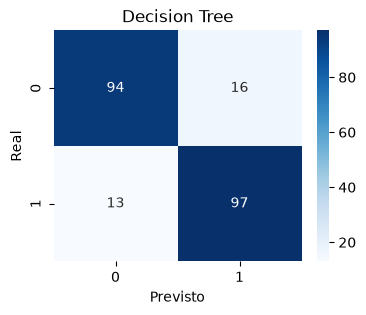

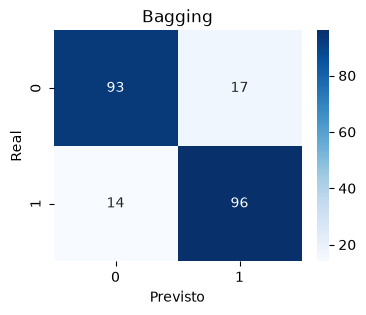

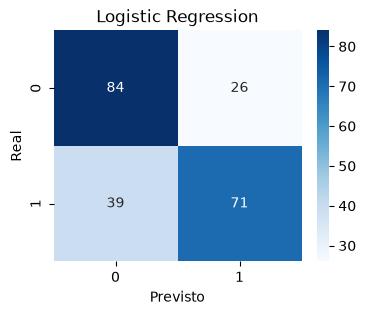

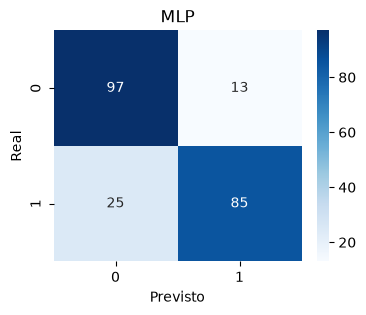

In [24]:
# Matrix Confusion 

for r in results:
    plot_cm(r["Modelo"], r["CM"])

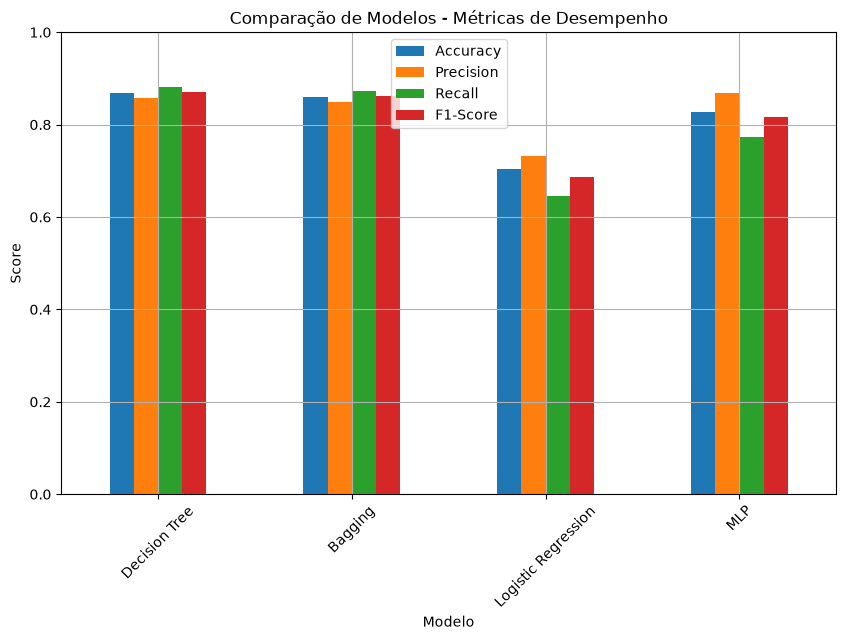

In [25]:
df.set_index("Modelo").plot(kind="bar", figsize=(10,6))
plt.title("Comparação de Modelos - Métricas de Desempenho")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=45)
plt.grid()
plt.show()

# Check-List

Com isso, você completa a fase 2 da disciplina. Para auxiliar você a verificar se o trabalho está adequado para a entrega, criamos uma lista de item que devem ser satisfeitos ao final do trabalho.

- Utilização de 4 algoritmos de classificação, incluindo Árvore de decisão e MLP; ✅
- Exploração dos hiper parâmetros dos algoritmos;✅
- Divisão do dataset em treino e teste, com estratificação na coluna alvo;✅
- Validação dos algoritmos usando cross-validation e coleta das métricas de avaliação (acurácia, precisão, recall, f1, matriz de confusão);✅
- Analise da matriz de confusão e métricas.✅
- Plotagem e análise textual sobre os resultados, indicando melhor modelo de IA;✅
- Conclusão do trabalho realizado, comentando os resultados e as dificuldades encontradas;✅
